## Selective Context Retention

Long-form conversational Transformers face a fundamental scalability challenge: as context length increases, indiscriminately attending to all tokens becomes both computationally expensive and semantically suboptimal. Not all tokens contribute equally to future predictions, and retaining irrelevant or redundant information can degrade performance over extended dialogues.

We propose **Selective Context Retention**, a lightweight mechanism that explicitly learns *which tokens to retain and which to forget* during sequence processing. Our approach consists of two core components: (1) deterministic positional encoding to preserve temporal structure, and (2) a learned retention head that assigns per-token importance scores.

Refer_1: [Beyond Attention: Breaking the Limits of Transformer Context Length](https://arxiv.org/html/2502.14048v1#bib.bib2)

Refer_2: [Beyond Attention (PDF)](https://lims.ac.uk/documents/paper-beyond-attention-breaking-the-limits-of-transformer-context-length-with-recurrent-memory.pdf)

<div style="display: flex; gap: 20px; justify-content: center;">
  <img src="x1.png" alt="Positional Encoding 1" width="350"/>
  <img src="x2.png" alt="Positional Encoding 2" width="350"/>
</div>

In [75]:
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import math
from torch.utils.tensorboard import SummaryWriter

In [83]:
!pip install tensorboard ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 19.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 31.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [78]:
class PositionalEncoding(torch.nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

In [79]:
import matplotlib.pyplot as plt

def log_positional_encoding(pe, writer, step=0, max_pos=100, max_dim=64):
    pe_slice = pe.pe[0, :max_pos, :max_dim].detach().cpu()

    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(pe_slice.T, aspect="auto")
    ax.set_xlabel("Position")
    ax.set_ylabel("Embedding Dimension")
    ax.set_title("Sinusoidal Positional Encoding")
    fig.colorbar(im, ax=ax)

    writer.add_figure("PositionalEncoding/Heatmap", fig, step)
    plt.close(fig)

In [80]:
writer = SummaryWriter(log_dir="runs/selective_retention")
embedding = torch.nn.Embedding(10000, 512)
pe = PositionalEncoding(512)
log_positional_encoding(pe, writer)

tokens = torch.randint(0, 10000, (4, 20))
x = embedding(tokens)

x = pe(x)
x

tensor([[[-3.0080e-01,  1.2848e+00,  1.1213e+00,  ...,  3.0016e+00,
           7.4129e-01,  7.2256e-01],
         [ 8.9994e-01,  1.2164e+00,  1.3582e+00,  ...,  1.1747e+00,
          -4.8256e-01,  1.6258e+00],
         [ 2.4733e+00,  4.7843e-01,  1.1725e+00,  ...,  1.6047e+00,
           5.3285e-01,  1.2181e+00],
         ...,
         [-1.2128e+00, -1.0280e-03, -1.3242e+00,  ...,  2.3218e-02,
           1.0224e+00,  7.4400e-01],
         [-9.0715e-01,  9.4507e-01, -1.5038e+00,  ...,  1.8445e+00,
          -2.3456e-01,  2.8633e+00],
         [ 4.0579e-01,  2.5696e+00, -5.2560e-01,  ...,  1.1336e+00,
          -6.2844e-01,  2.0035e+00]],

        [[-1.3497e+00,  1.2856e+00, -1.1619e-01,  ...,  1.7271e+00,
          -9.4060e-01,  9.4769e-01],
         [ 1.7526e+00, -1.7270e+00,  9.3456e-01,  ...,  2.2245e-01,
           1.0524e+00,  8.3403e-01],
         [ 7.9650e-01, -1.0084e+00,  1.2155e+00,  ...,  8.2736e-01,
           1.9216e+00,  7.3745e-01],
         ...,
         [-1.1041e+00,  3

## 3.1 Positional Encoding for Long-Form Context

Let the token embedding sequence be $X \in \mathbb{R}^{B \times T \times d}$.  
To inject information about token order, we use sinusoidal positional encodings  
$P \in \mathbb{R}^{T \times d}$, defined as:

$$
P_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i / d}}\right)
\quad
P_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i / d}}\right)
$$

These positional encodings are added element-wise to the token embeddings:

$$
X' = X + P
$$

By using sine and cosine functions at different frequencies, the model gains a
clear sense of absolute token positions while also being able to reason about
relative distances between tokens. Since these encodings are fixed rather than
learned, they naturally generalize to sequence lengths longer than those seen
during training. This makes them well suited for long-form text and extended
conversational contexts.

In [86]:
%reload_ext tensorboard 

In [91]:
import pkg_resources
print("pkg_resources OK")

ModuleNotFoundError: No module named 'pkg_resources'

In [93]:
%tensorboard --logdir runs/selective_retention

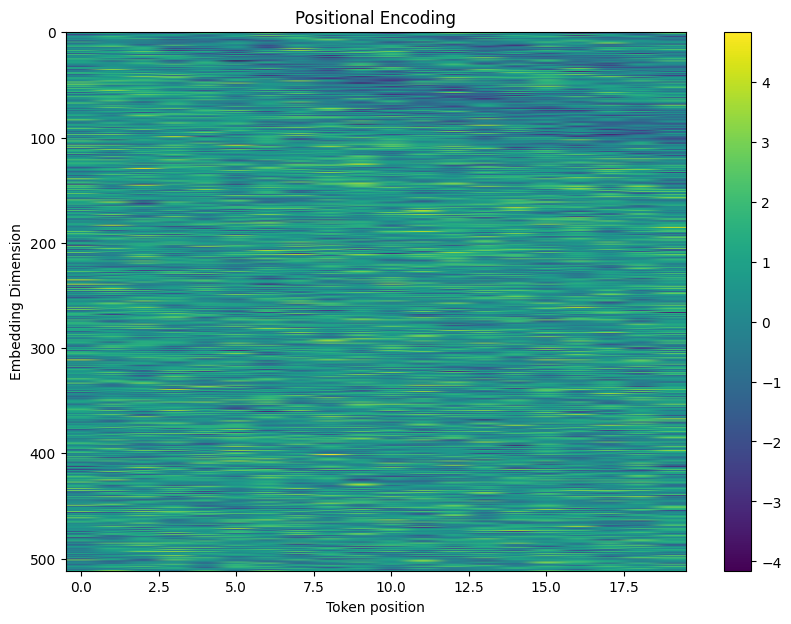

In [58]:
sample = x[0]


plt.figure(figsize=(10, 7))
plt.imshow(sample.T.detach().cpu(), aspect='auto')
plt.colorbar()
plt.xlabel("Token position")
plt.ylabel("Embedding Dimension")
plt.title("Positional Encoding")
plt.show()

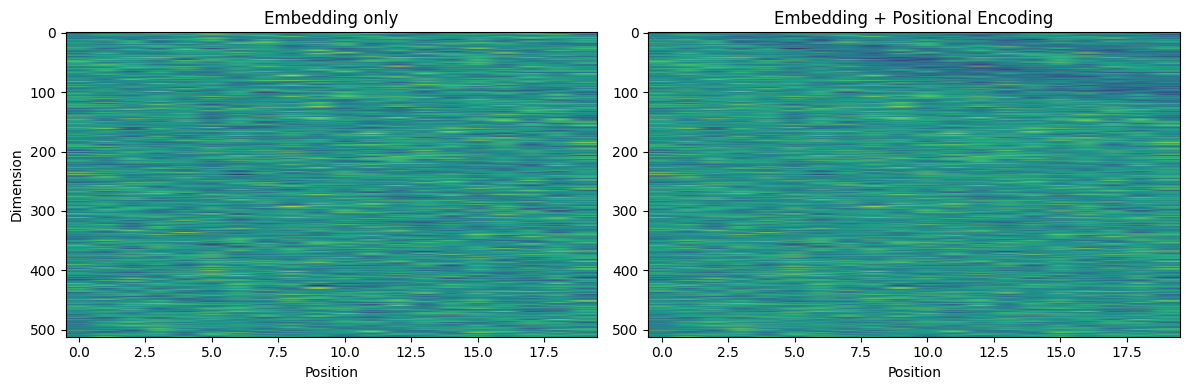

In [61]:
x_embed = embedding(tokens)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(x_embed[0].T.detach().cpu(), aspect='auto')
plt.title("Embedding only")
plt.xlabel("Position")
plt.ylabel("Dimension")

plt.subplot(1, 2, 2)
plt.imshow(x[0].T.detach().cpu(), aspect='auto')
plt.title("Embedding + Positional Encoding")
plt.xlabel("Position")

plt.tight_layout()
plt.show()

In [50]:
class RetentionHead(torch.nn.Module):
    def __init__(self, d_model, hidden=128):
        super().__init__()
        self.ff = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, x):
        logits = self.ff(x).squeeze(-1)
        return logits


In [62]:
import torch
import torch.nn as nn

B, T, D = 4, 20, 512

x = torch.randn(B, T, D)
head = RetentionHead(d_model=D)

logits = head(x)

print("Input shape :", x.shape)
print("Output shape:", logits.shape)

Input shape : torch.Size([4, 20, 512])
Output shape: torch.Size([4, 20])


In [63]:
print("Min:", logits.min().item())
print("Max:", logits.max().item())
print("Mean:", logits.mean().item())

Min: -0.4192054867744446
Max: 0.6504071354866028
Mean: 0.03228973597288132


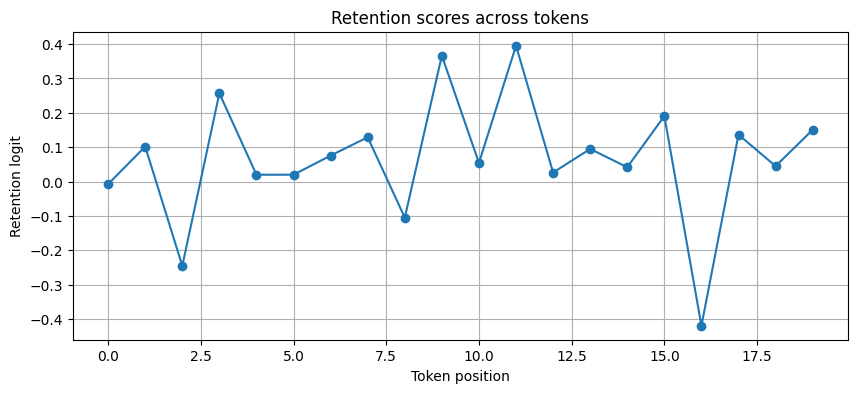

In [64]:
import matplotlib.pyplot as plt

sample_logits = logits[0].detach().numpy() 

plt.figure(figsize=(10, 4))
plt.plot(sample_logits, marker='o')
plt.xlabel("Token position")
plt.ylabel("Retention logit")
plt.title("Retention scores across tokens")
plt.grid(True)
plt.show()

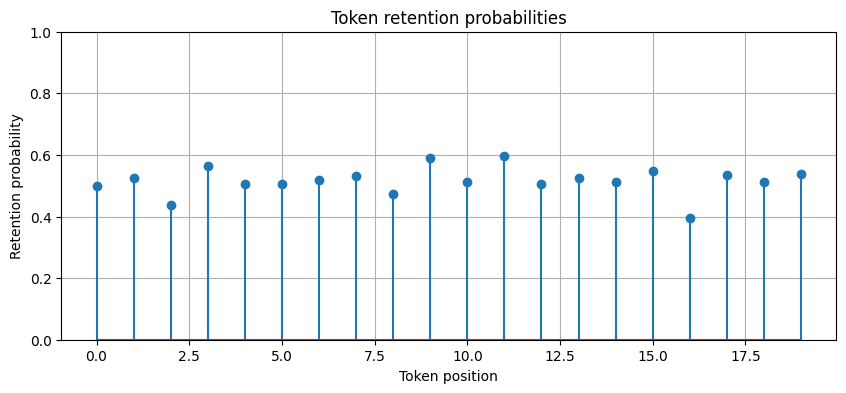

In [69]:
scores = torch.sigmoid(logits[0]).detach().numpy()

plt.figure(figsize=(10, 4))
plt.stem(scores)
plt.xlabel("Token position")
plt.ylabel("Retention probability")
plt.title("Token retention probabilities")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

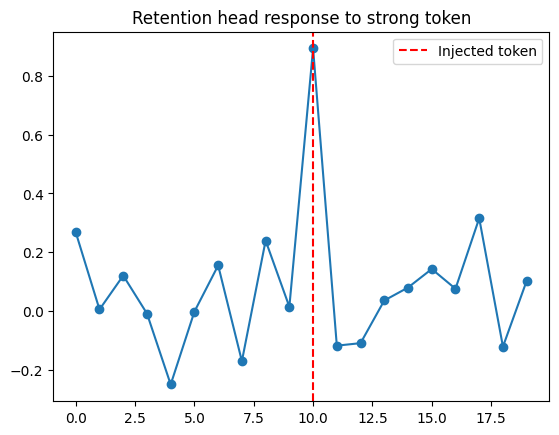

In [71]:
x = torch.randn(1, 20, 512)
x[:, 10, :] += 5.0 

logits = head(x)

plt.plot(logits[0].detach().numpy(), marker='o')
plt.axvline(10, color='r', linestyle='--', label='Injected token')
plt.legend()
plt.title("Retention head response to strong token")
plt.show()

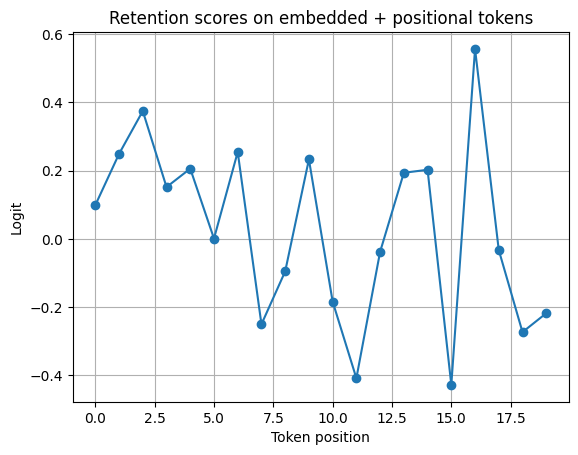

In [72]:
embedding = nn.Embedding(10000, 512)
pe = PositionalEncoding(512)
head = RetentionHead(512)

tokens = torch.randint(0, 10000, (1, 20))
x = embedding(tokens)
x = pe(x)

logits = head(x)

plt.plot(logits[0].detach().numpy(), marker='o')
plt.title("Retention scores on embedded + positional tokens")
plt.xlabel("Token position")
plt.ylabel("Logit")
plt.grid(True)
plt.show()

## Semantic Decomposition

Semantic decomposition is a technique that involves sequentially breaking down input
prompts in a predefined, **hierarchical** manner. The goal is to allow an LLM-driven
agent pipeline to decompose user inputs in a way that conforms to a system’s required
schema.

By splitting complex prompts into discrete and manageable segments, automated systems
can more reliably interpret intent and execute multi-stage pipelines from natural
language instructions. This structured decomposition improves precision and helps
generate more accurate and contextually relevant responses.

<div style="display: flex; gap: 20px; justify-content: center;">
  <img src="x3.png" alt="Semantic decomposition stage 1" width="350"/>
  <img src="x4.png" alt="Semantic decomposition stage 2" width="350"/>
</div>

In [67]:

class TransformerLMWithRetention(torch.nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.1, max_len=512):
        super().__init__()
        self.d_model = d_model
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=max_len)
        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, activation='relu')
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        self.lm_head = nn.Linear(d_model, vocab_size)
        self.retent = RetentionHead(d_model)
        self.max_len = max_len

    def forward(self, input_ids, temp=1.0, hard=False):
        emb = self.token_emb(input_ids) * math.sqrt(self.d_model)  
        emb = self.pos_enc(emb)
        logits = self.retent(emb)
        if self.training or (not hard):
            u = torch.rand_like(logits)
            g = -torch.log(-torch.log(u + 1e-9) + 1e-9)
            y = torch.sigmoid((logits + g) / temp)
            mask = y.unsqueeze(-1)
        else:
            mask = (torch.sigmoid(logits) > 0.5).float().unsqueeze(-1)

        masked_emb = emb * mask  
        x = masked_emb.transpose(0,1)
        out = self.transformer(x)  
        out = out.transpose(0,1)  
        logits_out = self.lm_head(out)  
        return logits_out, mask.squeeze(-1), logits  

In [ ]:
class DelayedRecallDataset:
    def __init__(self, vocab_size=50, seq_len=30, delay=15):
        self.vocab_size = vocab_size
        self.seq_len = seq_len
        self.delay = delay

    def sample(self, batch_size):
        x = torch.zeros(batch_size, self.seq_len, dtype=torch.long)
        y = torch.zeros(batch_size, dtype=torch.long)

        for b in range(batch_size):
            key = random.randint(1, self.vocab_size // 2)
            value = random.randint(self.vocab_size // 2 + 1, self.vocab_size - 1)

            noise = [random.randint(1, self.vocab_size - 1) for _ in range(self.delay)]
            query = key

            seq = [key, value] + noise + [query]
            seq = seq[: self.seq_len]
            x[b, : len(seq)] = torch.tensor(seq)
            y[b] = value

        return x, y

### Algorithm: Selective Context Retention with Recurrent Memory

**Input:**  
- Input segments: \( \{X_1, \dots, X_S\} \)  
- Memory size: \( K \)

**Output:**  
- Predictions: \( \{Y_1, \dots, Y_S\} \)

---

**Initialize:**  
- Memory \( M_0 \leftarrow \emptyset \)

---

**For** \( s = 1 \) to \( S \):

1. Concatenate memory and input  
   \[
   Z_s \leftarrow [M_{s-1}; X_s]
   \]

2. Encode with Transformer  
   \[
   H_s \leftarrow \text{Transformer}(Z_s)
   \]

3. **For each** token representation \( h_t \in H_s \):

   - Compute retention gate  
     \[
     r_t \leftarrow \sigma(W h_t + b)
     \]

   - Apply gating  
     \[
     \tilde{h}_t \leftarrow r_t \odot h_t
     \]

4. Update memory  
   \[
   M_s \leftarrow \text{TopK}(\tilde{H}_s, K)
   \]

5. Produce output  
   \[
   Y_s \leftarrow \text{OutputHead}(\tilde{H}_s^{(X_s)})
   \]